# **Import Libraries**

In [1]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split

# **Import Dataset**

In [2]:
zip_path = "/content/Dataset.zip"
extract_path = "/content/Dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = extract_path

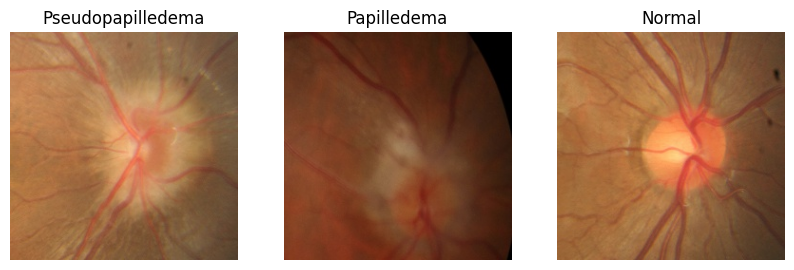

In [3]:
#Show_Dataset
class_names = os.listdir(dataset_path)
class_names = [cls for cls in class_names if os.path.isdir(os.path.join(dataset_path, cls))]

plt.figure(figsize=(10, 10))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)
    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [4]:
#Data_shape
image_size = (256, 256)
data = []
labels = []

for label, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path).resize(image_size)
        data.append(np.array(image))
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Initial data shape")
print(f"Data shape: {data.shape}, labels shape: {labels.shape}")

Initial data shape
Data shape: (1369, 256, 256, 3), labels shape: (1369,)


In [5]:
#Normalization
data = data / 255.0

In [6]:
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

print(f"x_train.shape: {x_train.shape}, x_test.shape: {x_test.shape}")


x_train.shape: (1095, 256, 256, 3), x_test.shape: (274, 256, 256, 3)


In [7]:
input_shape = (256, 256, 3)

In [8]:
input_img = keras.Input(shape=input_shape)

In [9]:
# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
encoder = layers.MaxPooling2D((2, 2), padding='same')(x)

flat = layers.Flatten()(encoder)

In [10]:
# Middle Layers
dense1 = layers.Dense(256, activation='relu')(flat)  # Increased this value for better representation
dense2 = layers.Dense(128, activation='relu')(dense1)  # Increased this value for better representation
dense3 = layers.Dense(32 * 32 * 128, activation='relu')(dense2)

In [11]:
# Decoder
reshaped = layers.Reshape((32, 32, 128))(dense3)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(reshaped)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoder = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)


In [12]:
#Autoencoder
autoencoder = keras.Model(input_img, decoder)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 131072)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      33,554,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 131072)              │      16,908,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 128, 128, 32)        │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_2 (UpSampling2D)       │ (None, 256, 256, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 256, 256, 3)         │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,829,827 (193.90 MB)

 Trainable params: 50,829,827 (193.90 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = autoencoder.fit(x_train, x_train, epochs=20, batch_size=32, shuffle=True, validation_data=(x_test, x_test))


Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 492s 14s/step - loss: 0.0028 - val_loss: 0.0029
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 503s 14s/step - loss: 0.0027 - val_loss: 0.0028
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 492s 14s/step - loss: 0.0027 - val_loss: 0.0028
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 503s 14s/step - loss: 0.0026 - val_loss: 0.0027
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 493s 14s/step - loss: 0.0024 - val_loss: 0.0026
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 503s 14s/step - loss: 0.0023 - val_loss: 0.0027
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 497s 14s/step - loss: 0.0024 - val_loss: 0.0026
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 498s 14s/step - loss: 0.0023 - val_loss: 0.0025
Epoch 9/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 509s 14s/step - loss: 0.0023 - val_loss: 0.0025
Epoch 10/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 504s 14s/step - loss: 0.0022 - val_loss: 0.0023
Epoch 11/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 538s 15s/step - loss: 0.0021 - val_loss: 0.0023
Epoch 12/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 526s 14s/step

In [17]:
decoded_imgs = autoencoder.predict(x_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step


# **Visualization**

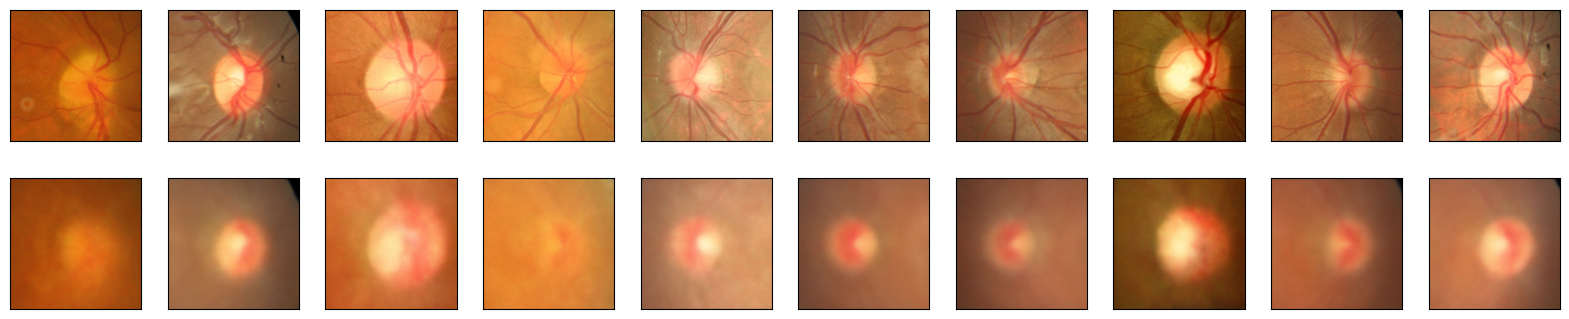

In [18]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

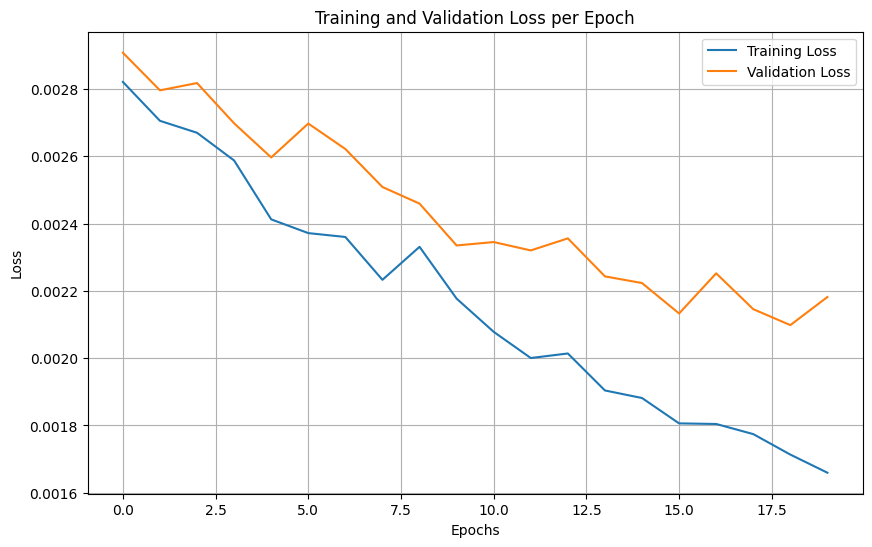

In [19]:
# Plotting the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()